In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import precision_score
# from sklearn.metircs import r2_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
df_d = pd.read_csv('diabetes.csv')

In [ ]:
df_d = df_d[df_d['Glucose']!=0]
# df_d.drop(index=df_d[df_d['Glucose']==0].index, axis=1)

In [ ]:
df_d[df_d['Glucose'] <= 75]['Outcome'].value_counts() # pure node, only 0s, so leaf node.

,count
Outcome,
0,25


In [ ]:
df_d.info()

<class 'pandas.core.frame.DataFrame'>
Index: 763 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               763 non-null    int64  
 1   Glucose                   763 non-null    int64  
 2   BloodPressure             763 non-null    int64  
 3   SkinThickness             763 non-null    int64  
 4   Insulin                   763 non-null    int64  
 5   BMI                       763 non-null    float64
 6   DiabetesPedigreeFunction  763 non-null    float64
 7   Age                       763 non-null    int64  
 8   Outcome                   763 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 59.6 KB


In [ ]:
df_d.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df_d.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df_d['Pregnancies'].value_counts()

In [ ]:
df_d.apply(lambda r: (r == '0').any(), axis=0)
# df_d['Pregnancies'] == 0

,0
Pregnancies,False
Glucose,False
BloodPressure,False
SkinThickness,False
Insulin,False
BMI,False
DiabetesPedigreeFunction,False
Age,False
Outcome,False


In [ ]:
# BP < 80 -> Low Pressure, BP >= 80 and BP <= 120 -> Normal, BP > 120 -> High Pressure?
df_d['BP'] = df_d['BloodPressure'].map(lambda x: 'Low Preasure' if x < 80 else
                          ('Normal' if x >= 80 and x <= 120 else 'High Preasure'))

In [ ]:
# -E p(x).log(p(x))
# stats probability
# df_d['BP'].value_counts()
# lb = 563 / 768
# hb = 1 / 768
# nor = 204 / 768
# (lb * np.log2(lb) + hb * np.log2(hb) + nor * np.log2(nor) ) * -1
-np.sum(df_d['BP'].value_counts(normalize=True) * np.log2(df_d['BP'].value_counts(normalize=True)))

np.float64(0.8488937951699136)

In [ ]:
(df_d['BloodPressure'] < 80).sum()

np.int64(563)

In [ ]:
from scipy.stats import entropy

In [ ]:
probs_bp = df_d['BP'].value_counts(normalize=True)
probs_bp

,proportion
BP,
Low Preasure,0.733073
Normal,0.265625
High Preasure,0.001302


In [ ]:
entropy(probs_bp, base=2)

NameError: name 'entropy' is not defined

In [ ]:
pdata = df_d.groupby(by=['Pregnancies','Outcome'])['Age'].count().reset_index().rename(columns={'Age' : 'count'})

In [ ]:
pdata

,Pregnancies,Outcome,count
0,0,0,73
1,0,1,38
2,1,0,106
3,1,1,29
4,2,0,84
5,2,1,19
6,3,0,48
7,3,1,27
8,4,0,45
9,4,1,23


<Axes: xlabel='Pregnancies', ylabel='count'>

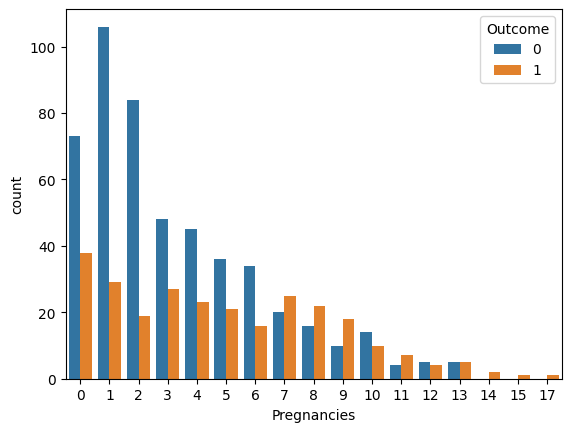

In [ ]:
sns.barplot(data=pdata, x='Pregnancies', y='count', hue='Outcome')

In [ ]:
for c in df_d.columns[:-2]:
  probs = df_d[c].value_counts(normalize=True)
  entr = entropy(probs, base=2)
  print(c,entr)


Pregnancies 3.4820480960305136
Glucose 6.751021001710518
BloodPressure 4.792469587589404
SkinThickness 4.5855913814785465
Insulin 4.681589542876211
BMI 7.5937573506351255
DiabetesPedigreeFunction 8.82850483152379
Age 5.028842203274248


In [ ]:
df_d['DiabetesPedigreeFunction'].value_counts()

,count
DiabetesPedigreeFunction,
0.258,6
0.254,6
0.207,5
0.261,5
0.259,5
...,...
0.565,1
0.118,1
0.177,1


In [ ]:
from scipy.stats import entropy

In [ ]:
df_dp_temp = df_d.groupby(by=['DiabetesPedigreeFunction','Outcome'])[['Age']]. \
count().reset_index().rename(columns={'Age':'count'}).\
merge(df_d['DiabetesPedigreeFunction'].\
      value_counts(normalize=True).reset_index(), how='inner', on='DiabetesPedigreeFunction')

#weighted entropy of childrean
# E ni/n(-Ep(x)*log(p(x)))

df_dp_temp.sort_values(by=['DiabetesPedigreeFunction', 'Outcome']) #['proportion']
# * np.log2(df_dp_temp['proportion'])



,DiabetesPedigreeFunction,Outcome,count,proportion
0,0.078,0,1,0.001302
1,0.084,0,1,0.001302
2,0.085,0,2,0.002604
3,0.088,0,1,0.002604
4,0.088,1,1,0.002604
...,...,...,...,...
598,1.893,1,1,0.001302
599,2.137,1,1,0.001302
600,2.288,1,1,0.001302
601,2.329,0,1,0.001302


In [ ]:
df_d[df_d['DiabetesPedigreeFunction'] == 0.078]
# DiabetesPedigreeFunction - is a continuos variable

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BP
268,0,102,52,0,0,25.1,0.078,21,0,Low Preasure


In [ ]:
pdf_1, bin_edges = np.histogram(df_d['DiabetesPedigreeFunction'], bins=10, density=True)
probs_dpf = pdf_1 / pdf_1.sum()
probs_dpf

array([0.4140625 , 0.26822917, 0.17708333, 0.07552083, 0.03255208,
       0.01953125, 0.00390625, 0.00390625, 0.00130208, 0.00390625])

In [ ]:
entropy(probs_dpf)

np.float64(1.481704122727364)

In [ ]:
# find root node :
# Gain(feature1) = Entropy(Sample) - Information(feature1)
# information(feature1) = Sum of Weighted avarage of entropy of childrean(distinct outcomes) of feature.

#1 Entropy(Sample) i.e Entropy(target variable):
probs_target = df_d['Outcome'].value_counts(normalize=True).values
entropy_target = -np.sum(probs_target * np.log2(probs_target))
print(entropy_target) # manula
entropy_target = entropy(probs_target,base=2) #from scipy.stats import entropy

#2 sum of weighted avg. entropy for childrean


#3 Gain or Information Gain or Entropy Gain, for a feature:

# childrean_entropies = df_d['DiabetesPedigreeFunction'].value_counts(normalize=True).sort_index().values *\
#  np.log2(df_d['DiabetesPedigreeFunction'].value_counts(normalize=True).sort_index().values)
# print('childrean_entropies',childrean_entropies)
# nodes_weighted_entropy = childrean_entropies \
#                            * (df_d['DiabetesPedigreeFunction'].value_counts().sort_index().values
#                               / df_d['DiabetesPedigreeFunction'].nunique())
# inform_gain_parent = entropy_target - np.sum(nodes_weighted_entropy)

# inform_gain_parent #manual gain measure for DiabetesPedigreeFunction


0.9331343166407831
childrean_entropies [-0.01248042 -0.01248042 -0.02235667 -0.02235667 -0.01248042 -0.01248042
 -0.01248042 -0.01248042 -0.01248042 -0.01248042 -0.01248042 -0.01248042
 -0.01248042 -0.01248042 -0.02235667 -0.01248042 -0.01248042 -0.02235667
 -0.02235667 -0.02235667 -0.02235667 -0.01248042 -0.01248042 -0.02235667
 -0.01248042 -0.01248042 -0.02235667 -0.01248042 -0.02235667 -0.03125
 -0.03125    -0.02235667 -0.01248042 -0.01248042 -0.01248042 -0.03125
 -0.01248042 -0.02235667 -0.03125    -0.02235667 -0.01248042 -0.01248042
 -0.01248042 -0.01248042 -0.02235667 -0.02235667 -0.01248042 -0.02235667
 -0.01248042 -0.01248042 -0.02235667 -0.03125    -0.01248042 -0.03950501
 -0.01248042 -0.01248042 -0.01248042 -0.01248042 -0.01248042 -0.01248042
 -0.01248042 -0.03125    -0.01248042 -0.02235667 -0.01248042 -0.01248042
 -0.02235667 -0.01248042 -0.03125    -0.01248042 -0.02235667 -0.03950501
 -0.02235667 -0.02235667 -0.01248042 -0.01248042 -0.03950501 -0.02235667
 -0.01248042 -0.03

np.float64(0.9650452555926925)

In [ ]:
df_d.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'BP'],
      dtype='object')

In [ ]:
from sklearn.feature_selection import mutual_info_calssif

In [ ]:
mutual_info_classif(df_d[['DiabetesPedigreeFunction']], df_d['Outcome'], discrete_features=True)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


array([0.4511818])

In [ ]:
# np.array([2,1]) * np.array([2,1])

np.int64(5)

In [ ]:
mutual_info_classif(df_d[['DiabetesPedigreeFunction']], df_d['Outcome'])


array([0.00751961])

In [ ]:
for c in df_d.columns[:-2]:
  print(c, mutual_info_classif(df_d[[c]],df_d['Outcome']))


Pregnancies [0.034461]
Glucose [0.13627923]
BloodPressure [0.00521688]
SkinThickness [0]
Insulin [0.04172935]
BMI [0.09607774]
DiabetesPedigreeFunction [0.01093469]
Age [0.04214205]


In [ ]:
df_d['Glucose'].value_counts() # continuous variable

,count
Glucose,
99,17
100,17
111,14
125,14
129,14
...,...
56,1
169,1
149,1


In [ ]:
# df_d = df_d.iloc[:,:-2]

In [ ]:
# df_d.info()
# df_d.corr()
df_d.duplicated().sum()

np.int64(0)

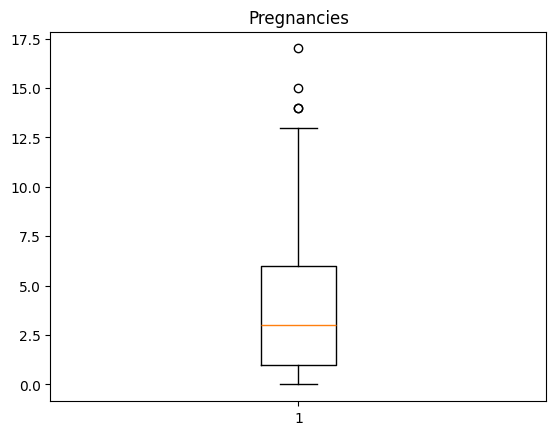

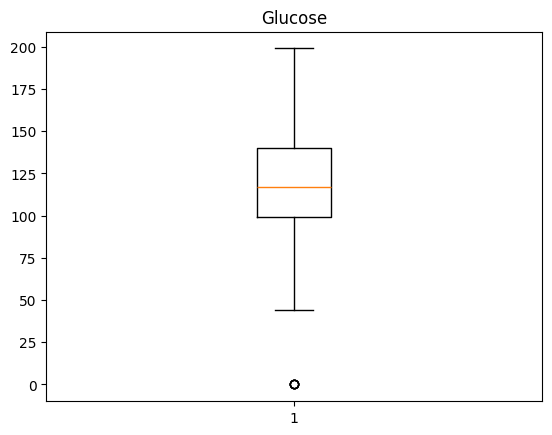

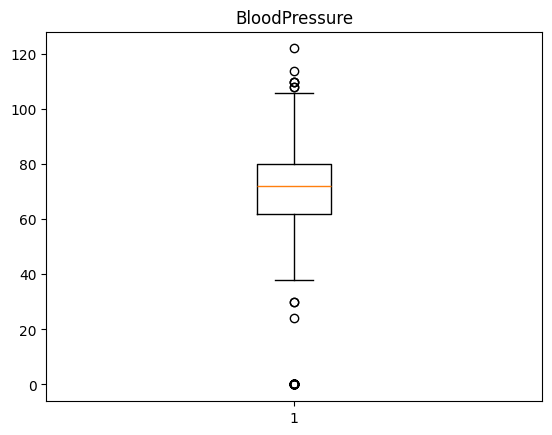

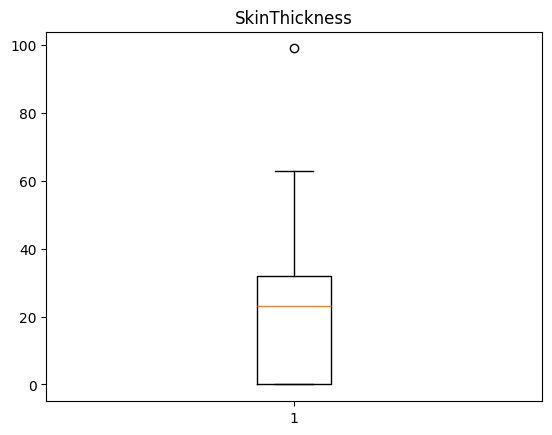

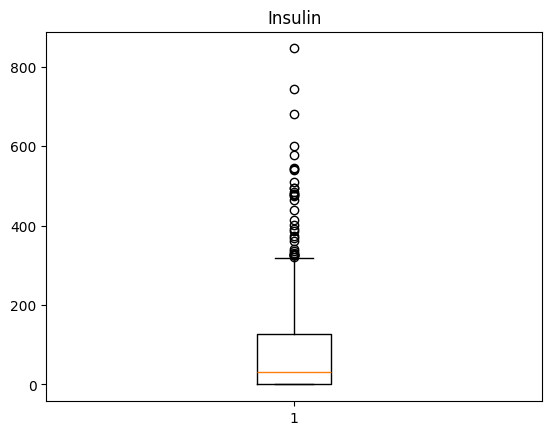

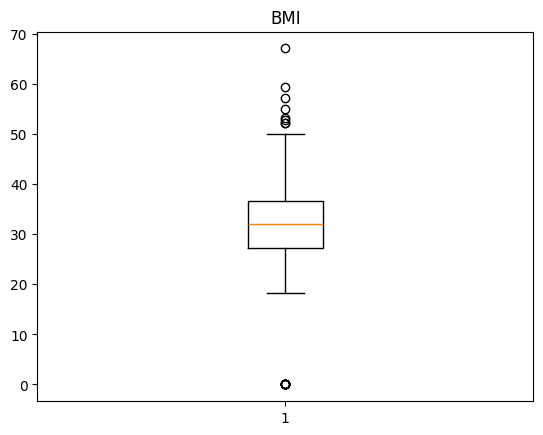

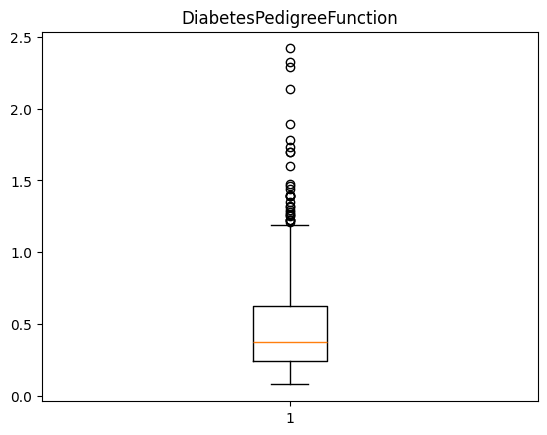

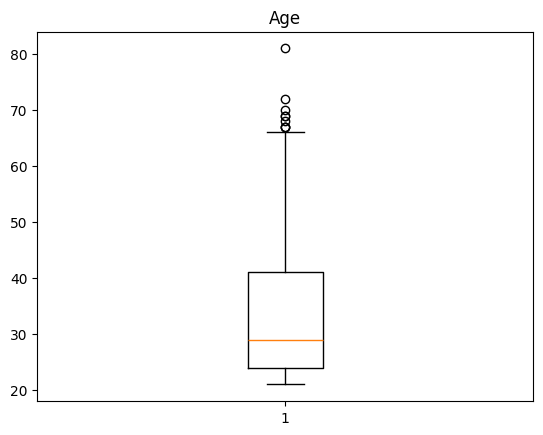

In [ ]:
for c in df_d.columns[:-1]:
  if df_d[c].dtype != 'object':
    plt.boxplot(df_d[c])
    plt.title(c)
    plt.show()

In [ ]:
df_d.shape

(768, 9)

In [ ]:
for c in df_d.columns[:-1]:
  if df_d[c].dtype != 'object':
    q1 = df_d[c].quantile(0.25)
    q3 = df_d[c].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - iqr * 1.5
    upper_limit = q3 + iqr * 1.5
    df_d = df_d[(df_d[c] >= lower_limit) & (df_d[c] <= upper_limit)]


In [ ]:
df_d.shape

(636, 9)

In [ ]:
X = df_d.iloc[:,:-1]
y = df_d.iloc[:,-1]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
model = DecisionTreeClassifier()


In [ ]:
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.7421875

In [ ]:
recall_score(y_test, y_pred)

0.5555555555555556

In [ ]:
model.tree_.feature
# X.columns[1]

array([ 1,  7,  1,  0,  5,  3, -2,  6,  2, -2,  6, -2,  6, -2, -2,  4, -2,
       -2, -2, -2,  0,  6,  4,  1, -2,  2,  3, -2, -2,  2,  7, -2, -2, -2,
       -2,  6,  1, -2, -2,  5,  6, -2,  3,  7, -2, -2, -2,  5,  2, -2,  0,
       -2, -2,  1,  1,  7,  5, -2,  7, -2, -2,  6, -2, -2, -2, -2, -2,  5,
        7, -2,  1, -2,  7, -2, -2,  1,  0, -2,  1, -2, -2,  6,  2,  3,  0,
       -2,  2, -2,  2, -2,  6,  0,  6, -2, -2,  6, -2,  3, -2,  3, -2, -2,
        6, -2,  7, -2,  5, -2, -2,  3, -2,  6, -2,  5,  6, -2, -2, -2,  4,
        2, -2, -2, -2,  0,  2, -2,  5,  4,  7, -2,  6,  1, -2, -2, -2, -2,
        7,  6, -2, -2, -2, -2,  7,  6,  6,  0, -2,  0, -2, -2, -2, -2,  6,
       -2, -2], dtype=int64)

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [2, 5, 10],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [2, 1, 3],
    'criterion': ['gini', 'entropy']
    }

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model = RandomForestClassifier(random_state=42)

In [ ]:
gs = GridSearchCV(estimator=model, param_grid=param_grid, cv=2)

In [ ]:
gs.fit(x_train, y_train)


GridSearchCV(cv=2, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 5, 10], 'min_samples_leaf': [2, 1, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [10, 50, 100]})

In [ ]:
gs.best_estimator_

RandomForestClassifier(max_depth=5, min_samples_leaf=2, n_estimators=50,
                       random_state=42)

In [ ]:
model = RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_split=2, min_samples_leaf=2)

In [ ]:
model.fit(x_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=2, n_estimators=50)

In [ ]:
np.array(y_test)

array([1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0])

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.7578125